# Building an Allen-Cahn Solver in STARK

This notebook is a guided walk-through of the STARK workflow.

We start with a PDE we want to solve, then build the adapter layer that lets STARK work with it. From there, the notebook becomes an investigation: not just whether a method produces the right answer, but where the computational cost is really coming from, and how much of that cost is avoidable.

We will:

1. define the PDE and the STARK adapter layer,
2. try explicit methods and compare them,
3. inspect the adaptive controller to see how the solver is behaving,
4. try a fully implicit Newton-based method,
5. split the PDE as IMEX and build a custom spectral resolvent,
6. re-run the important methods on the same problem,
7. use the best-structured method on a larger grid to produce the final graphics.


## 1. The PDE

We solve the one-dimensional periodic Allen-Cahn equation

$$
u_t = D u_{xx} + u - u^3.
$$

There are two natural parts:

- **diffusion**: $D u_{xx}$
- **reaction**: $u - u^3$

This observation will be important later on.

The first step towards a solver for this system is to decide how to represent the state.
We choose to discretise $u$ as an array, so its spatial derivatives become finite differences on a grid.
That means we begin by defining the geometry of the discretised system:

In [1]:
from dataclasses import dataclass, field
import numpy as np

@dataclass(slots=True)
class Geometry:
    length: float = 6.0
    grid_size: int = 364
    _dx: float | None = field(init=False, repr=True, default=None)
    _x: np.ndarray | None = field(init=False, repr=False, default=None)
    @property
    def dx(self) -> float:
        dx = self._dx
        if dx is None:
            dx = self.length / self.grid_size
            self._dx = dx
        return dx
    @property
    def x(self) -> np.ndarray:
        x = self._x
        if x is None:
            x = np.linspace(0.0, self.length, self.grid_size, endpoint=False, dtype=np.float64)
            self._x = x
        return x
    

Equipped with this geometry object, which carries the periodic cell length and the numerical grid size and spacing, we are ready to define the "state" of the Allen-Cahn system. Here we build an Allen-Cahn state as a lightweight wrapper over a NumPy array, together with custom initialisation schemes and a few useful diagnostics.

In [2]:
@dataclass(slots=True)
class AllenCahnState:
    u: np.ndarray
    @classmethod
    def init_zero(cls, geometry: Geometry) -> "AllenCahnState":
        return cls(u=np.zeros(geometry.grid_size))
    @classmethod
    def init_example(cls, geometry: Geometry) -> "AllenCahnState":
        x = np.linspace(0.0, geometry.length, geometry.grid_size, endpoint=False)
        k = 2.0 * np.pi / geometry.length
        u = 0.5 * np.sin(k*x) + 0.5 * np.sin(3*k*x)
        return AllenCahnState(u.astype(np.float64))
    @property
    def mean(self) -> float:
        return self.u.mean()
    @property
    def max(self) -> float:
        return self.u.max()
    @property
    def min(self) -> float:
        return self.u.min()

Let's pause here to make sure we can initialise the state and view its properties...

mean: 0.0000, max: 0.7697, min: -0.7697


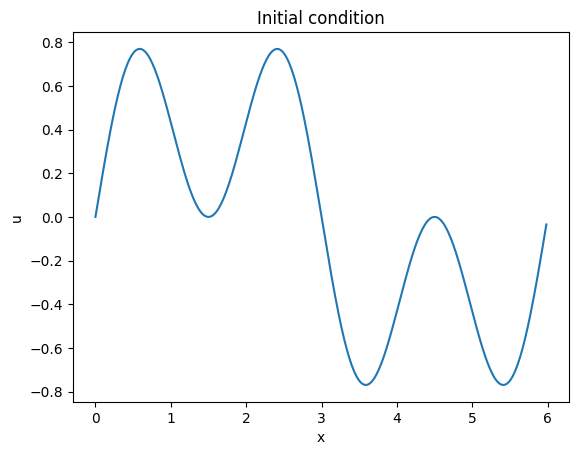

In [3]:
from matplotlib import pyplot as plt
GEOMETRY = Geometry()
state = AllenCahnState.init_example(GEOMETRY)
print(f"mean: {state.mean:.4f}, max: {state.max:.4f}, min: {state.min:.4f}")    
plt.plot(GEOMETRY.x, state.u)
plt.xlabel("x")
plt.ylabel("u")
plt.title("Initial condition")
plt.show()

Now that we have settled on the structure of the state, the next step in the STARK process is to build a bridge to the STARK solvers by defining translations on the space of states.
We have reason to expect this to be a computationally intensive system to solve (due to the nonlinearity of the PDE) so we will help speed things up by invoking a STARK accelerator that enables just-in-time compilation, passing the job itself onto numba, and by explicitly defining some fast paths for linear combinations.

(If you do not have numba installed, comment out the first two lines of the next code block!)

In [4]:
from stark.accelerators import AcceleratorNumba
ACCELERATOR = AcceleratorNumba()

class AllenCahnTranslation:
    __slots__ = ["du"]
    
    @staticmethod
    @ACCELERATOR.decorate
    def apply_kernel(result_u, origin_u, delta_u):
        result_u[:] = origin_u + delta_u

    @staticmethod
    @ACCELERATOR.decorate
    def norm_kernel(delta_u):
        total = 0.0
        size = delta_u.size
        for value in delta_u:
            total += value * value
        return (total / size) ** 0.5

    @staticmethod
    @ACCELERATOR.decorate
    def scale_kernel(out_u, a, x_u):
        out_u[:] = a * x_u

    @staticmethod
    @ACCELERATOR.decorate
    def combine2_kernel(out_u, a0, x0_u, a1, x1_u):
        out_u[:] = a0 * x0_u + a1 * x1_u

    @staticmethod
    @ACCELERATOR.decorate
    def combine3_kernel(out_u, a0, x0_u, a1, x1_u, a2, x2_u):
        out_u[:] = a0 * x0_u + a1 * x1_u + a2 * x2_u

    def __init__(self, du: np.ndarray) -> None:
        self.du = du

    def __call__(self, origin: AllenCahnState, result: AllenCahnState) -> None:
        self.apply_kernel(result.u, origin.u, self.du)

    def norm(self) -> float:
        return float(self.norm_kernel(self.du))

    def __add__(self, other: AllenCahnTranslation) -> AllenCahnTranslation:
        return AllenCahnTranslation(self.du + other.du)

    def __rmul__(self, scalar: float) -> AllenCahnTranslation:
        return AllenCahnTranslation(scalar * self.du)

    @staticmethod
    def scale(out, a, x):
        AllenCahnTranslation.scale_kernel(out.du, a, x.du)
        return out

    @staticmethod
    def combine2(out, a0, x0, a1, x1):
        AllenCahnTranslation.combine2_kernel(out.du, a0, x0.du, a1, x1.du)
        return out

    @staticmethod
    def combine3(out, a0, x0, a1, x1, a2, x2):
        AllenCahnTranslation.combine3_kernel(out.du, a0, x0.du, a1, x1.du, a2, x2.du)
        return out

    linear_combine = [scale, combine2, combine3]


Now that we can tell STARK what a translation looks like, we are ready to define the derivative.

The derivative for the Allen-Cahn system has a diffusion part and a reaction part. The diffusion part contains the Laplacian, which we have to discretise onto our chosen numerical grid.

The Allen-Cahn system contains one parameter, the diffusivity D, which we can make the derivative carry a copy of.

The call signature for a STARK-compliant derivative needs to take something interval-like as an argument, so we will import STARK's built-in interval.

In [5]:
from stark import Interval

class AllenCahnDerivative:
    _compiled = False

    def __init__(self, geometry: Geometry, diffusivity: float) -> None:
        self.geo = geometry
        self.diffusivity = diffusivity
        self.inv_dx2 = 1.0 / (geometry.dx * geometry.dx)
        self.laplacian_u = np.zeros(geometry.grid_size, dtype=np.float64)
        if not self.__class__._compiled:
            probe = np.zeros(geometry.grid_size, dtype=np.float64)
            ACCELERATOR.compile_examples(self.laplacian_periodic, (probe, probe, self.inv_dx2))
            ACCELERATOR.compile_examples(self.full_rhs, (probe, probe, probe, self.diffusivity))
            self.__class__._compiled = True

    def __call__(self, interval: Interval, state: AllenCahnState, out: AllenCahnTranslation) -> None:
        del interval
        self.laplacian_periodic(state.u, self.laplacian_u, self.inv_dx2)
        self.full_rhs(state.u, self.laplacian_u, out.du, self.diffusivity)
    
    @staticmethod
    @ACCELERATOR.decorate
    def laplacian_periodic(field, out, inv_dx2):
        size = field.size
        for index in range(size):
            left = field[index - 1 if index > 0 else size - 1]
            centre = field[index]
            right = field[index + 1 if index + 1 < size else 0]
            out[index] = (left - 2.0 * centre + right) * inv_dx2

    @staticmethod
    @ACCELERATOR.decorate
    def full_rhs(u, laplacian_u, out_u, diffusivity):
        out_u[:] = diffusivity * laplacian_u + u - u * u * u

    @staticmethod
    @ACCELERATOR.decorate
    def reaction_rhs(u, out_u):
        out_u[:] = u - u * u * u

    @staticmethod
    @ACCELERATOR.decorate
    def diffusion_rhs(laplacian_u, out_u, diffusivity):
        out_u[:] = diffusivity * laplacian_u

The final thing STARK needs to work with before we can make a first attempt at integrating the Allen-Cahn system is a "workbench" object, telling STARK how we want it to allocate workspace to states and translations.

The workbench can also tell the accelerator to attempt to compile various parts of the translation on example data, which will speed up future applications.

In [6]:
class AllenCahnWorkbench:
    __slots__ = ("grid_size",)
    _compiled = False

    def __init__(self, geometry: Geometry) -> None:
        self.grid_size = geometry.grid_size
        if not self.__class__._compiled:
            probe = np.zeros(self.grid_size, dtype=np.float64)
            ACCELERATOR.compile_examples(AllenCahnTranslation.apply_kernel, (probe, probe, probe))
            ACCELERATOR.compile_examples(AllenCahnTranslation.norm_kernel, (probe,))
            ACCELERATOR.compile_examples(AllenCahnTranslation.scale_kernel, (probe, 1.0, probe))
            ACCELERATOR.compile_examples(AllenCahnTranslation.combine2_kernel, (probe, 1.0, probe, 1.0, probe))
            ACCELERATOR.compile_examples(
                AllenCahnTranslation.combine3_kernel,
                (probe, 1.0, probe, 1.0, probe, 1.0, probe),
            )
            self.__class__._compiled = True

    def allocate_state(self) -> AllenCahnState:
        return AllenCahnState(np.zeros(self.grid_size, dtype=np.float64))

    def copy_state(self, dst: AllenCahnState, src: AllenCahnState) -> None:
        np.copyto(dst.u, src.u)

    def allocate_translation(self) -> AllenCahnTranslation:
        return AllenCahnTranslation(np.zeros(self.grid_size, dtype=np.float64))

As a good habit, we will collect together all the parameters we need for an integration run and pass the objects we have created through a STARK audit to make sure everything has the right shape.

As a first attempt at integrating this system, we will try a simple Cash-Karp adaptive Runge-Kutta scheme.

In [7]:
from stark import Auditor, Tolerance
from stark.schemes import SchemeCashKarp
DIFFUSIVITY: float = 0.08
TOLERANCE = Tolerance(atol=1.0e-6, rtol=1.0e-3)
START_TIME = 0.0
STOP_TIME = 1.0
INITIAL_STEP = 1.0e-3
GEOMETRY = Geometry()
interval = Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME)
workbench = AllenCahnWorkbench(geometry=GEOMETRY)
derivative = AllenCahnDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
translation = workbench.allocate_translation()
state = AllenCahnState.init_example(GEOMETRY)
scheme = SchemeCashKarp(derivative, workbench)
audit = Auditor(
        state=state,
        derivative=derivative,
        translation=translation,
        workbench=workbench,
        interval=interval,
        scheme=scheme,
        tolerance=TOLERANCE,
    )
print(audit)
audit.raise_if_invalid()

STARK audit checklist
Object      | Required behavior                                        | Present
------------+----------------------------------------------------------+--------
Interval    | Interval provides present                                | yes    
Interval    | Interval provides step                                   | yes    
Interval    | Interval provides stop                                   | yes    
Interval    | Interval provides increment(dt)                          | yes    
Interval    | Interval provides copy()                                 | yes    
Interval    | Interval.copy() succeeds                                 | yes    
Interval    | Interval.copy() preserves present, step, and stop        | yes    
Interval    | Interval.increment(dt) advances present on a copy        | yes    
Derivative  | Derivative is callable                                   | yes    
Derivative  | Derivative(interval, state, translation) can be called   | yes    
Transl

The audit comes back clean, so we are safe to proceed with a trial run.

t: 0.2000, mean: 0.0000, max: 0.7617, min: -0.7617
t: 0.4000, mean: 0.0000, max: 0.7659, min: -0.7659
t: 0.6000, mean: 0.0000, max: 0.7764, min: -0.7764
t: 0.8000, mean: 0.0000, max: 0.7911, min: -0.7911
t: 1.0000, mean: 0.0000, max: 0.8089, min: -0.8089


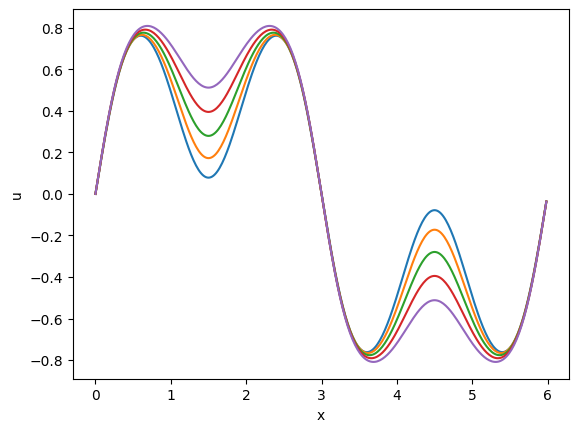

In [8]:

from stark.execution.executor import Executor
from stark import Marcher, Integrator

DIFFUSIVITY: float = 0.08
TOLERANCE = Tolerance(atol=1.0e-6, rtol=1.0e-3)
START_TIME = 0.0
STOP_TIME = 1.0
INITIAL_STEP = 1.0e-3
executor = Executor(tolerance=TOLERANCE)
integrate = Integrator(executor=executor)
derivative = AllenCahnDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
workbench = AllenCahnWorkbench(geometry=GEOMETRY)
scheme = SchemeCashKarp(derivative, workbench)
marcher = Marcher(scheme, executor)
interval = Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME)
state = AllenCahnState.init_example(GEOMETRY)

fig, ax = plt.subplots()
ax.set_xlabel("x")
ax.set_ylabel("u")

for _, _ in integrate.live(marcher=marcher, interval=interval, state=state, checkpoints=5):
    print(f"t: {interval.present:.4f}, mean: {state.mean:.4f}, max: {state.max:.4f}, min: {state.min:.4f}")
    ax.plot(GEOMETRY.x, state.u)

This is a promising start, but how can we know whether it is truly accurate?

One option here is to try a different solution scheme and see if we get the same result.

To demonstrate the principle, we will compare the solution from a Cash-Karp scheme with the solution from a Dormand-Prince scheme.

STARK provides the ability to compare different methods using the Comparator class.

In [9]:
from stark import Executor, Interval, Marcher, Tolerance
from stark.schemes import SchemeCashKarp, SchemeDormandPrince
from stark.comparison import Comparator, ComparatorProblem, ComparatorEntry

DIFFUSIVITY: float = 0.08
TOLERANCE = Tolerance(atol=1.0e-6, rtol=1.0e-3)
START_TIME = 0.0
STOP_TIME = 1.0
INITIAL_STEP = 1.0e-3

derivative = AllenCahnDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
workbench = AllenCahnWorkbench(geometry=GEOMETRY)

scheme_ck = SchemeCashKarp(derivative, workbench)
scheme_dp = SchemeDormandPrince(derivative, workbench)

executor = Executor(tolerance=TOLERANCE)

marcher_ck = Marcher(scheme_ck, executor)
marcher_dp = Marcher(scheme_dp, executor)


def state_difference(left: AllenCahnState, right: AllenCahnState) -> float:
    diff = left.u - right.u
    return float((diff @ diff / diff.size) ** 0.5)

def state_diagnostics(state: AllenCahnState) -> dict[str, float]:
    return {
        "mean": float(state.u.mean()),
        "max": float(state.u.max()),
        "min": float(state.u.min()),
    }

entry_ck = ComparatorEntry(
    "Cash-Karp",
    marcher_ck,
)

entry_dp = ComparatorEntry(
    "Dormand-Prince",
    marcher_dp,
)

problem = ComparatorProblem(
    name="Allen-Cahn",
    build_state=lambda: AllenCahnState.init_example(GEOMETRY),
    build_interval=lambda: Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME),
    difference=state_difference,
    diagnostics=state_diagnostics,
)

report = Comparator(problem, [entry_ck, entry_dp], repeats=3)()
print(report)

Allen-Cahn comparison

Each entry is warmed once, timed 3 times, and profiled once.
Setup excludes one-time cross-entry builder warmup costs.

Timing Table
entry          | setup     | warmup    | median    | min      
---------------+-----------+-----------+-----------+----------
Cash-Karp      | 0.000036s | 0.013321s | 0.011857s | 0.011414s
Dormand-Prince | 0.000076s | 0.013059s | 0.012512s | 0.012446s

Pairwise final-state differences
entry          | Cash-Karp    | Dormand-Prince
---------------+--------------+---------------
Cash-Karp      | 0.000000e+00 | 2.233802e-07  
Dormand-Prince | 2.233802e-07 | 0.000000e+00  

Diagnostics Table
Rows show problem-supplied final-state diagnostics from ComparatorProblem.diagnostics(...).
entry          | steps | mean         | max      | min      
---------------+-------+--------------+----------+----------
Cash-Karp      | 303   | 2.92338e-13  | 0.808898 | -0.808897
Dormand-Prince | 346   | -4.23729e-12 | 0.808897 | -0.808898

Profile breakd

The two schemes agree, as shown in the final-state difference table. This is a promising sign.

We can check how well the integration scheme is coping, at the cost of slowing it down slightly, by running a monitored integration.

A useful diagnostic for an adaptive controller is the error ratio over time. This error ratio can be read roughly as
 - < 1: accepted comfortably
 - = 1: right on the acceptance boundary
 - \> 1: too large, so the trial step should be rejected
 
As we track the error ratio over time, a useful rule of thumb is
 - 0.1 to 0.5: conservative stepping
 - 0.5 to 1.0: healthy efficient stepping
 - repeatedly just under 1.0 with few rejections: usually fine
 - repeatedly crossing above 1.0 and forcing retries: controller is hunting too aggressively

Text(0.5, 1.0, 'Cash-Karp error-ratio trace')

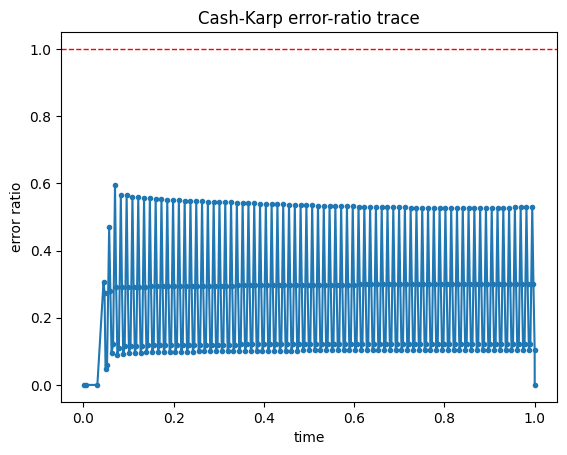

In [10]:

from stark import Integrator, Interval, Marcher
from stark.execution.executor import Executor
from stark.monitor import Monitor
from stark.schemes import SchemeCashKarp

derivative = AllenCahnDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
workbench = AllenCahnWorkbench(geometry=GEOMETRY)
executor = Executor(tolerance=TOLERANCE)
integrate = Integrator(executor=executor)
scheme = SchemeCashKarp(derivative, workbench)
marcher = Marcher(scheme, executor)
monitor = Monitor()

interval = Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME)
state = AllenCahnState.init_example(GEOMETRY)

list(
    integrate.live_monitored(
        marcher=marcher,
        interval=interval,
        state=state,
        monitor=monitor,
    )
)

times = [step.t_end for step in monitor.steps]
error_ratio = [step.error_ratio for step in monitor.steps]

fig, ax = plt.subplots()

ax.plot(times, error_ratio, marker=".")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("time")
ax.set_ylabel("error ratio")
ax.set_title("Cash-Karp error-ratio trace")


We observe that the explicit solver is being very conservative, so it is doing more work than is strictly required to reach the end result.

This can be an indication that the method is not a particularly efficient match for the problem.

That does not mean the explicit result is wrong. It means that, at this tolerance, the adaptive controller is being forced to take many cautious steps to keep the local error under control.

That inefficiency becomes especially costly if we want to scale up the size of the system.

To address this "conservatism" problem, we next attempt an implicit method.

Implicit methods need to solve a (typically nonlinear) equation to determine the state at the next time step.

STARK makes no assumptions about the concrete state type it is evolving. The downside is that the built-in equation-solving options are limited to methods that can be expressed purely in terms of (blocks of) translations. Advanced users are encouraged to build their own custom resolvents, tailored to their particular states, if the built-in resolvents are too slow.

For our attempt at an implicit solution, we will use the adaptive ESDIRK 2(1) scheme with the built-in Newton solver.

The Newton solver requires us to supply it with a "linearizer" that constructs the Jacobian as an operator on translations.

At a high level, the roles are as follows. The scheme decides which stage equation needs to be solved, the resolvent manages that nonlinear solve, the linearizer supplies Jacobian information, and the inverter solves the linear correction problem that Newton produces.

On the finite grid the full derivative is

$$
f(u) = DLu + u - u^3,
$$

where $L$ is the periodic finite-difference Laplacian.

Expanding this around $u$ gives


$$
f(u+\delta u) = DLu + DL\delta u + u + \delta u - u^3 - 3 u^2\delta u + O(\delta u^2)
\\= f(u) + DL\delta u + (1 - 3u^2)\delta u + O(\delta u^2)
$$

so the Jacobian "linearizer" required by the Newton method is


$$
J(u)[v] = DLv + (1 - 3u^2)v.
$$

We define this in code below...

In [11]:
class AllenCahnJacobianOperator:
    __slots__ = ("diffusivity", "inv_dx2", "laplacian_u", "u")

    def __init__(self, geometry: Geometry, diffusivity: float) -> None:
        self.diffusivity = diffusivity
        self.inv_dx2 = 1.0 / (geometry.dx * geometry.dx)
        self.laplacian_u = np.zeros(geometry.grid_size, dtype=np.float64)
        self.u: np.ndarray | None = None

    def configure(self, state: AllenCahnState) -> None:
        self.u = state.u

    @staticmethod
    @ACCELERATOR.decorate
    def jacobian_apply(u, translation_u, laplacian_u, result_u, diffusivity):
        result_u[:] = diffusivity * laplacian_u + (1.0 - 3.0 * u * u) * translation_u

    def __call__(self, result: AllenCahnTranslation, translation: AllenCahnTranslation) -> None:
        u = self.u
        assert u is not None
        AllenCahnDerivative.laplacian_periodic(translation.du, self.laplacian_u, self.inv_dx2)
        self.jacobian_apply(u, translation.du, self.laplacian_u, result.du, self.diffusivity)


class AllenCahnLinearizer:
    __slots__ = ("operator",)
    _compiled = False

    def __init__(self, geometry: Geometry, diffusivity: float) -> None:
        self.operator = AllenCahnJacobianOperator(geometry, diffusivity)
        if not self.__class__._compiled:
            probe = np.zeros(geometry.grid_size, dtype=np.float64)
            ACCELERATOR.compile_examples(
                AllenCahnJacobianOperator.jacobian_apply,
                (probe, probe, probe, probe, diffusivity),
            )
            self.__class__._compiled = True

    def __call__(self, interval: Interval, out, state: AllenCahnState) -> None:
        del interval
        self.operator.configure(state)
        out.apply = self.operator


Our chosen Newton resolvent also requires an inverter to solve the linear systems it produces, so we pass it a BiCGStab Krylov inverter. This inverter in turn requires an inner product to be defined on translations, which we produce below.

In [12]:
def allen_cahn_inner_product(left: AllenCahnTranslation, right: AllenCahnTranslation) -> float:
    return float(np.dot(left.du, right.du))

Now we plug these ingredients into a Newton solver, and then plug that into our chosen implicit method...

In [13]:
from stark import Executor, Interval, Marcher, Tolerance
from stark.comparison import Comparator, ComparatorEntry, ComparatorProblem
from stark.inverters import InverterBiCGStab, InverterPolicy, InverterTolerance
from stark.resolvents import ResolventNewton, ResolventTolerance, ResolventPolicy
from stark.schemes import SchemeCashKarp, SchemeSDIRK21
GEOMETRY = Geometry()
DIFFUSIVITY: float = 0.08
TOLERANCE = Tolerance(atol=1.0e-6, rtol=1.0e-3)
START_TIME = 0.0
STOP_TIME = 1.0
INITIAL_STEP = 1.0e-3

derivative = AllenCahnDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
workbench = AllenCahnWorkbench(geometry=GEOMETRY)


executor = Executor(tolerance=TOLERANCE)

linearizer = AllenCahnLinearizer(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
inverter = InverterBiCGStab(
            workbench,
            allen_cahn_inner_product,
            tolerance=InverterTolerance(atol=1.0e-7, rtol=1.0e-7),
            policy=InverterPolicy(max_iterations=24, restart=12),
            safety=executor.safety,
        )
resolvent = ResolventNewton(
            derivative,
            workbench,
            linearizer=linearizer,
            inverter=inverter,
            tolerance=ResolventTolerance(atol=1.0e-7, rtol=1.0e-7),
            policy=ResolventPolicy(max_iterations=12),
            safety=executor.safety,
            accelerator=executor.accelerator,
            tableau=SchemeSDIRK21.tableau,
        )
scheme_sdk = SchemeSDIRK21(derivative, workbench, resolvent)
scheme_ck = SchemeCashKarp(derivative, workbench)

marcher_sdk = Marcher(scheme_sdk, executor)
marcher_ck = Marcher(scheme_ck, executor)


def state_difference(left: AllenCahnState, right: AllenCahnState) -> float:
    diff = left.u - right.u
    return float((diff @ diff / diff.size) ** 0.5)

def state_diagnostics(state: AllenCahnState) -> dict[str, float]:
    return {
        "mean": float(state.u.mean()),
        "max": float(state.u.max()),
        "min": float(state.u.min()),
    }

entry_sdk = ComparatorEntry("ESDIRK 2(1)", marcher_sdk)
entry_ck = ComparatorEntry("Cash-Karp", marcher_ck)


problem = ComparatorProblem(
    name="Allen-Cahn",
    build_state=lambda: AllenCahnState.init_example(GEOMETRY),
    build_interval=lambda: Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME),
    difference=state_difference,
    diagnostics=state_diagnostics,
)

report = Comparator(problem, [entry_sdk, entry_ck], repeats=3)()
print(report)


Allen-Cahn comparison

Each entry is warmed once, timed 3 times, and profiled once.
Setup excludes one-time cross-entry builder warmup costs.

Timing Table
entry       | setup     | warmup    | median    | min      
------------+-----------+-----------+-----------+----------
ESDIRK 2(1) | 0.000027s | 0.034291s | 0.030777s | 0.030338s
Cash-Karp   | 0.000097s | 0.011348s | 0.011396s | 0.011296s

Pairwise final-state differences
entry       | ESDIRK 2(1)  | Cash-Karp   
------------+--------------+-------------
ESDIRK 2(1) | 0.000000e+00 | 2.358946e-06
Cash-Karp   | 2.358946e-06 | 0.000000e+00

Diagnostics Table
Rows show problem-supplied final-state diagnostics from ComparatorProblem.diagnostics(...).
entry       | steps | mean        | max      | min      
------------+-------+-------------+----------+----------
ESDIRK 2(1) | 117   | 0           | 0.808897 | -0.808897
Cash-Karp   | 303   | 2.92338e-13 | 0.808898 | -0.808897

Profile breakdown by self time
Rows show the share of profiled

The implicit solver is taking fewer steps, which should in principle make it faster, but it is actually much slower.

The profile breakdown shows us why this is the case: it is spending a plurality of its time in the inverter.

So fewer macro steps do not automatically imply a faster solve. Each implicit step is carrying much more internal work, and on this problem that extra work dominates the savings from taking larger time steps.

In the Allen-Cahn equation, the reaction term is nonlinear, while the diffusion term is linear. That suggests an implicit-explicit (IMEX) split: treat the linear diffusion implicitly, and keep the nonlinear reaction explicit.

That is, we split the Allen-Cahn derivative into two parts:

$$
u_t = f_{\mathrm{im}}(u) + f_{\mathrm{ex}}(u).
$$

with

$$
f_{\mathrm{im}}(u) = DLu,
\qquad
f_{\mathrm{ex}}(u) = u - u^3.
$$

In [14]:
class AllenCahnImplicitDerivative:
    __slots__ = ("diffusivity", "inv_dx2", "laplacian_u")

    def __init__(self, geometry: Geometry, diffusivity: float) -> None:
        self.diffusivity = diffusivity
        self.inv_dx2 = 1.0 / (geometry.dx * geometry.dx)
        self.laplacian_u = np.zeros(geometry.grid_size, dtype=np.float64)

    def __call__(self, interval: Interval, state: AllenCahnState, out: AllenCahnTranslation) -> None:
        del interval
        AllenCahnDerivative.laplacian_periodic(state.u, self.laplacian_u, self.inv_dx2)
        out.du[:] = self.diffusivity * self.laplacian_u


class AllenCahnExplicitDerivative:
    __slots__ = ()

    def __init__(self, geometry: Geometry) -> None:
        del geometry

    def __call__(self, interval: Interval, state: AllenCahnState, out: AllenCahnTranslation) -> None:
        del interval
        out.du[:] = state.u - state.u**3


The attraction of this split is that a linear implicit operator can sometimes be inverted directly. If we can do that here, we can supply a custom resolvent that avoids the expensive generic inverter phase that dominated the fully implicit run.

Before writing that resolvent, we should first ask the IMEX scheme what stage equation it expects the resolvent to solve:


In [15]:
from stark.schemes import SchemeKennedyCarpenter43_7

print("Implicit stage problem for KC43-7")
print("---------------------------------")
print(SchemeKennedyCarpenter43_7.display_resolvent_problem())


Implicit stage problem for KC43-7
---------------------------------
KC43-7 IMEX resolvent problem (Kennedy-Carpenter 4(3) 7-stage)

Unknown stage block:
    Delta = (Delta_1, ..., Delta_7)

Solve for Delta so that, for i = 1, ..., s,

    Delta_i - h * sum_{j=1}^s a^im_{ij} f_im(t_n + c_j h, x_n + Delta_j) - h * sum_{j=1}^s a^ex_{ij} f_ex(t_n + c_j h, x_n + Delta_j) = 0

Then advance with

    x_{n+1} = x_n + h * sum_{j=1}^s b^im_j f_im(t_n + c_j h, x_n + Delta_j) + h * sum_{j=1}^s b^ex_j f_ex(t_n + c_j h, x_n + Delta_j)

Here a^im_{ij}, a^ex_{ij}, b^im_j, b^ex_j, and c_j come from the IMEX Butcher tableau pair.

Because the implicit tableau is lower triangular, STARK can choose to resolve the implicit stage corrections sequentially.

A custom resolvent for this method must accept arguments `(out, alpha, rhs=None)` and overwrite `out` with the solution block of the equation above, stored as `Block(Translation, Translation, ...)`.


For the Allen-Cahn equation we split the derivative as

$$
f_{\mathrm{im}}(u) = DLu,
\qquad
f_{\mathrm{ex}}(u) = u - u^3,
$$

where $L$ is the periodic finite-difference Laplacian.

If we write the stage state as

$$
U_i = u_n + \Delta_i,
$$

then the generic IMEX stage equation becomes

$$
U_i
- h \sum_{j=1}^s a^{\mathrm{im}}_{ij} D L U_j
- h \sum_{j=1}^s a^{\mathrm{ex}}_{ij} (U_j - U_j^3)
= u_n.
$$

Because the implicit tableau is lower triangular, the stage indexed by $i$ only depends implicitly on the current stage and earlier ones. So once the previous stages are known, the unknown $U_i$ satisfies

$$
\bigl(I - h a^{\mathrm{im}}_{ii} D L\bigr) U_i
=
u_n
+ h \sum_{j<i} a^{\mathrm{im}}_{ij} D L U_j
+ h \sum_{j<i} a^{\mathrm{ex}}_{ij} (U_j - U_j^3).
$$

This is the key simplification: the nonlinear reaction term stays on the explicit side, so it is already known when stage $i$ is being solved. The only thing left to invert is the linear diffusion operator

$$
I - h a^{\mathrm{im}}_{ii} D L.
$$

So, for Allen-Cahn, a custom IMEX resolvent does not need to solve a nonlinear equation at all. It only needs to solve a sequence of linear diffusion problems, one stage at a time.


On a periodic grid, the Laplacian is diagonal in Fourier space. If $\widehat{U}_i(k)$ denotes the Fourier coefficient of the stage state at wave number $k$, then the stage solve

$$
\bigl(I - h a^{\mathrm{im}}_{ii} D L\bigr) U_i = \mathrm{rhs}_i
$$

becomes, mode by mode,

$$
\bigl(1 - h a^{\mathrm{im}}_{ii} D \lambda_k\bigr)\widehat{U}_i(k)
=
\widehat{\mathrm{rhs}}_i(k),
$$

where $\lambda_k$ is the Laplacian eigenvalue for mode $k$.

So each Fourier mode is solved independently by simple division:

$$
\widehat{U}_i(k)
=
\frac{\widehat{\mathrm{rhs}}_i(k)}
{1 - h a^{\mathrm{im}}_{ii} D \lambda_k}.
$$

That is why this IMEX split is attractive here. We are no longer asking STARK to run a generic nonlinear resolvent or iterative linear inverter. Instead, we can write down the stage solve explicitly in spectral space, invert it directly, and transform back.

For the standard second-order periodic finite-difference Laplacian with grid spacing $\Delta x$, the eigenvalues are

$$
\lambda_k
=
-\frac{4}{\Delta x^2}\sin^2\!\left(\frac{\pi k}{N}\right).
$$


For this split Allen-Cahn problem, the custom resolvent only needs to handle the linear diffusion solve that STARK presents in the form

$$
\delta - \mathrm{rhs} - \alpha D L(u + \delta) = 0.
$$

Here $u$ is the currently bound stage state, $\delta$ is the unknown stage correction, and $\alpha$ is the diagonal implicit coefficient supplied by the IMEX method.

Because the grid is periodic, the discrete Laplacian is diagonal in Fourier space. That means we can solve this equation exactly, mode by mode, with no nonlinear iteration and no Krylov inverter.

So the resolvent below does three things:
1. `bind(...)` stores the current stage state,
2. `__call__(...)` receives the shifted diffusion solve from the scheme,
3. the actual solve is done directly in Fourier space and written back into `out`.


In [16]:
class AllenCahnSpectralResolvent:
    def __init__(self, geometry: Geometry, diffusivity: float) -> None:
        theta = 2.0 * np.pi * np.fft.fftfreq(geometry.grid_size)
        inv_dx2 = 1.0 / (geometry.dx * geometry.dx)
        self.operator_symbol = diffusivity * 2.0 * (np.cos(theta) - 1.0) * inv_dx2
        self.spectrum = np.zeros(geometry.grid_size, dtype=np.complex128)
        self.state_u: np.ndarray | None = None

    def bind(self, interval: Interval, state: AllenCahnState) -> None:
        del interval
        self.state_u = state.u

    def __call__(self, out, alpha: float, rhs=None) -> None:
        base_u = self.state_u
        assert base_u is not None

        self.spectrum[:] = np.fft.fft(base_u)
        self.spectrum[:] *= alpha * self.operator_symbol

        if rhs is not None:
            self.spectrum[:] += np.fft.fft(rhs[0].du)

        self.spectrum[:] /= 1.0 - alpha * self.operator_symbol
        out[0].du[:] = np.fft.ifft(self.spectrum).real

With that resolvent in place, the IMEX setup looks much like the earlier implicit examples. The main difference is that we now split the derivative into an implicit diffusion part and an explicit reaction part, then pass the custom spectral resolvent into the scheme.

This gives STARK everything it needs to march the Allen-Cahn system with an IMEX method while avoiding the generic nonlinear and linear solve machinery from the fully implicit run.


In [17]:
from stark import Executor, Integrator, Interval, Marcher, Tolerance
from stark.contracts import ImExDerivative
from stark.schemes import SchemeKennedyCarpenter43_7

DIFFUSIVITY: float = 0.08
TOLERANCE = Tolerance(atol=1.0e-6, rtol=1.0e-3)
START_TIME = 0.0
STOP_TIME = 1.0
INITIAL_STEP = 1.0e-3

GEOMETRY = Geometry()

implicit_derivative = AllenCahnImplicitDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
explicit_derivative = AllenCahnExplicitDerivative(geometry=GEOMETRY)
derivative = ImExDerivative(implicit=implicit_derivative, explicit=explicit_derivative)

workbench = AllenCahnWorkbench(geometry=GEOMETRY)
resolvent = AllenCahnSpectralResolvent(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)

scheme = SchemeKennedyCarpenter43_7(derivative, workbench, resolvent=resolvent)
executor = Executor(tolerance=TOLERANCE)
integrate = Integrator(executor=executor)
marcher = Marcher(scheme, executor)

interval = Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME)
state = AllenCahnState.init_example(GEOMETRY)

for snapshot_interval, snapshot_state in integrate(
    marcher=marcher,
    interval=interval,
    state=state,
    checkpoints=5,
):
    print(
        f"t: {snapshot_interval.present:.4f}, "
        f"mean: {snapshot_state.mean:.4f}, "
        f"max: {snapshot_state.max:.4f}, "
        f"min: {snapshot_state.min:.4f}"
    )


t: 0.2000, mean: 0.0000, max: 0.7617, min: -0.7617
t: 0.4000, mean: 0.0000, max: 0.7659, min: -0.7659
t: 0.6000, mean: 0.0000, max: 0.7764, min: -0.7764
t: 0.8000, mean: 0.0000, max: 0.7911, min: -0.7911
t: 1.0000, mean: 0.0000, max: 0.8089, min: -0.8089


At this point, a single IMEX run only tells us that the custom resolvent works. The more interesting question is whether it actually improves the solve.

So we now compare three approaches on the same Allen-Cahn problem:
- an adaptive explicit method,
- an adaptive fully implicit method with Newton,
- and the custom IMEX method with the spectral diffusion resolvent.

This lets us see whether the IMEX split really delivers a better balance between step count and internal cost.

In [18]:
from stark import Executor, Interval, Marcher, Tolerance
from stark.comparison import Comparator, ComparatorEntry, ComparatorProblem
from stark.contracts import ImExDerivative
from stark.inverters import InverterBiCGStab, InverterPolicy, InverterTolerance
from stark.resolvents import ResolventNewton, ResolventPolicy, ResolventTolerance
from stark.schemes import SchemeCashKarp, SchemeKennedyCarpenter43_7, SchemeSDIRK21

GEOMETRY = Geometry()
DIFFUSIVITY: float = 0.08
TOLERANCE = Tolerance(atol=1.0e-6, rtol=1.0e-3)
START_TIME = 0.0
STOP_TIME = 1.0
INITIAL_STEP = 1.0e-3

derivative = AllenCahnDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
implicit_derivative = AllenCahnImplicitDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
explicit_derivative = AllenCahnExplicitDerivative(geometry=GEOMETRY)
imex_derivative = ImExDerivative(implicit=implicit_derivative, explicit=explicit_derivative)

workbench = AllenCahnWorkbench(geometry=GEOMETRY)
executor = Executor(tolerance=TOLERANCE)

scheme_ck = SchemeCashKarp(derivative, workbench)
marcher_ck = Marcher(scheme_ck, executor)

linearizer = AllenCahnLinearizer(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
inverter = InverterBiCGStab(
    workbench,
    allen_cahn_inner_product,
    tolerance=InverterTolerance(atol=1.0e-7, rtol=1.0e-7),
    policy=InverterPolicy(max_iterations=24, restart=12),
    safety=executor.safety,
)
resolvent_newton = ResolventNewton(
    derivative,
    workbench,
    linearizer=linearizer,
    inverter=inverter,
    tolerance=ResolventTolerance(atol=1.0e-7, rtol=1.0e-7),
    policy=ResolventPolicy(max_iterations=12),
    safety=executor.safety,
    accelerator=executor.accelerator,
    tableau=SchemeSDIRK21.tableau,
)
scheme_sdirk = SchemeSDIRK21(derivative, workbench, resolvent_newton)
marcher_sdirk = Marcher(scheme_sdirk, executor)

resolvent_imex = AllenCahnSpectralResolvent(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
scheme_imex = SchemeKennedyCarpenter43_7(imex_derivative, workbench, resolvent=resolvent_imex)
marcher_imex = Marcher(scheme_imex, executor)

def state_difference(left: AllenCahnState, right: AllenCahnState) -> float:
    diff = left.u - right.u
    return float((diff @ diff / diff.size) ** 0.5)

def state_diagnostics(state: AllenCahnState) -> dict[str, float]:
    return {
        "mean": float(state.u.mean()),
        "max": float(state.u.max()),
        "min": float(state.u.min()),
    }

problem = ComparatorProblem(
    name="Allen-Cahn",
    build_state=lambda: AllenCahnState.init_example(GEOMETRY),
    build_interval=lambda: Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME),
    difference=state_difference,
    diagnostics=state_diagnostics,
)

entries = [
    ComparatorEntry("Cash-Karp", marcher_ck),
    ComparatorEntry("SDIRK21 Newton", marcher_sdirk),
    ComparatorEntry("KC43-7 IMEX Spectral", marcher_imex),
]

report = Comparator(problem, entries, repeats=3)()
print(report)


Allen-Cahn comparison

Each entry is warmed once, timed 3 times, and profiled once.
Setup excludes one-time cross-entry builder warmup costs.

Timing Table
entry                | setup     | warmup    | median    | min      
---------------------+-----------+-----------+-----------+----------
Cash-Karp            | 0.000033s | 0.012282s | 0.011389s | 0.011181s
SDIRK21 Newton       | 0.000075s | 0.031989s | 0.031457s | 0.031269s
KC43-7 IMEX Spectral | 0.000073s | 0.002020s | 0.001854s | 0.001831s

Pairwise final-state differences
entry                | Cash-Karp    | SDIRK21 Newton | KC43-7 IMEX Spectral
---------------------+--------------+----------------+---------------------
Cash-Karp            | 0.000000e+00 | 2.358946e-06   | 2.478821e-05        
SDIRK21 Newton       | 2.358946e-06 | 0.000000e+00   | 2.558833e-05        
KC43-7 IMEX Spectral | 2.478821e-05 | 2.558833e-05   | 0.000000e+00        

Diagnostics Table
Rows show problem-supplied final-state diagnostics from Comparator

At the smaller grid size, the IMEX method has shown that the split is not just mathematically neat, but computationally worthwhile.

For a final demonstration, we now increase the size of the spatial grid and use the IMEX marcher to generate a higher-resolution solution. The goal here is no longer to compare methods, but to use the method that has emerged from the story and let it produce a clean picture of the Allen-Cahn dynamics.

We will record the evolving field over time and then visualise both:
- the full space-time evolution,
- and the initial and final profiles.

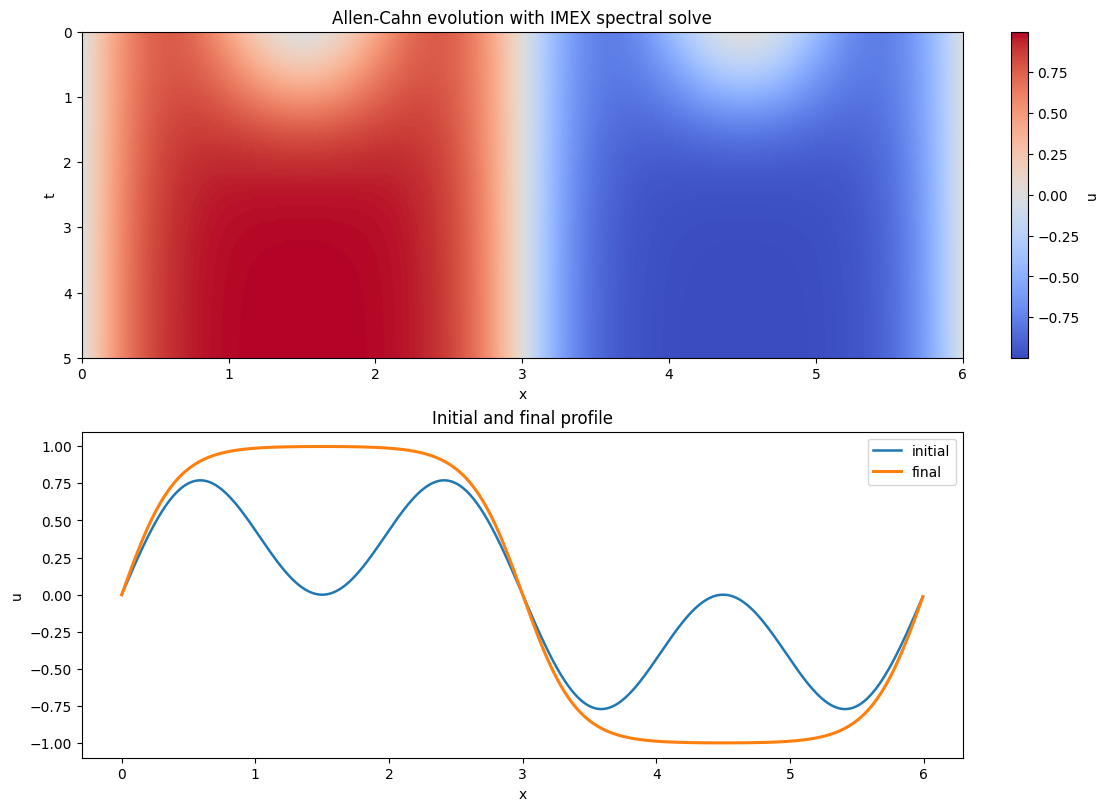

In [19]:
import matplotlib.pyplot as plt
import numpy as np

from stark import Executor, Integrator, Interval, Marcher, Tolerance
from stark.contracts import ImExDerivative
from stark.schemes import SchemeKennedyCarpenter43_7

GEOMETRY = Geometry(grid_size=1024)
DIFFUSIVITY: float = 0.08
TOLERANCE = Tolerance(atol=1.0e-6, rtol=1.0e-3)
START_TIME = 0.0
STOP_TIME = 5.0
INITIAL_STEP = 1.5e-3

implicit_derivative = AllenCahnImplicitDerivative(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)
explicit_derivative = AllenCahnExplicitDerivative(geometry=GEOMETRY)
derivative = ImExDerivative(implicit=implicit_derivative, explicit=explicit_derivative)

workbench = AllenCahnWorkbench(geometry=GEOMETRY)
resolvent = AllenCahnSpectralResolvent(geometry=GEOMETRY, diffusivity=DIFFUSIVITY)

scheme = SchemeKennedyCarpenter43_7(derivative, workbench, resolvent=resolvent)
executor = Executor(tolerance=TOLERANCE)
integrate = Integrator(executor=executor)
marcher = Marcher(scheme, executor)

state = AllenCahnState.init_example(GEOMETRY)
initial_profile = state.u.copy()
interval = Interval(present=START_TIME, step=INITIAL_STEP, stop=STOP_TIME)
checkpoints = np.linspace(START_TIME, STOP_TIME, 120)[1:]

times = [START_TIME]
frames = [state.u.copy()]

for snapshot_interval, snapshot_state in integrate(
    marcher=marcher,
    interval=interval,
    state=state,
    checkpoints=checkpoints,
):
    times.append(float(snapshot_interval.present))
    frames.append(snapshot_state.u.copy())

times = np.asarray(times)
frames = np.asarray(frames)
x = np.linspace(0.0, GEOMETRY.length, GEOMETRY.grid_size, endpoint=False)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

image = axes[0].imshow(
    frames,
    aspect="auto",
    cmap="coolwarm",
    extent=(0.0, GEOMETRY.length, times[-1], times[0]),
)
axes[0].set_title("Allen-Cahn evolution with IMEX spectral solve")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
fig.colorbar(image, ax=axes[0], label="u")

axes[1].plot(x, initial_profile, linewidth=1.8, label="initial")
axes[1].plot(x, frames[-1], linewidth=2.2, label="final")
axes[1].set_title("Initial and final profile")
axes[1].set_xlabel("x")
axes[1].set_ylabel("u")
axes[1].legend(loc="upper right")

plt.show()


## Conclusion

The point of this notebook was not just to solve Allen-Cahn once, but to show how a STARK solver can be built up methodically.

We began with the basic problem definition, then added only as much numerical machinery as the situation demanded. First that meant explicit schemes, then monitoring, then a linearizer, then a Newton resolvent, and finally an IMEX split with a custom spectral solve. At each stage, the question was the same: what extra structure do we need, and is it worth the cost?

That is the habit this notebook is meant to teach. In STARK, you do not have to commit to the most complicated solver at the start. You can begin with a simple working model, test it, inspect its behaviour, and then introduce more specialised machinery only when the problem justifies it.

For Allen-Cahn, that process led us to the IMEX spectral method. For another problem, it may lead somewhere else. The important lesson is how to make that decision.
